## ネットワーク分析（SIRモデルなど）
https://www.nii.ac.jp/userdata/shimin/documents/H19/071113_6thlec.pdf

ノード：ネットワークの点、個々の要素

エッジ：ノード間の接続、関係性

次数：1つのノードに接続されているエッジの数

L: 平均最短経路長
-  ネットワーク内の任意の2ノード間の最短経路の平均値

C: クラスタリング係数
- あるノードの隣接ノード同士がどれだけ互いに接続されているかを示す指標
- 0から1の範囲で表され、1に近いほど隣接ノード同士が接続されていることを示す

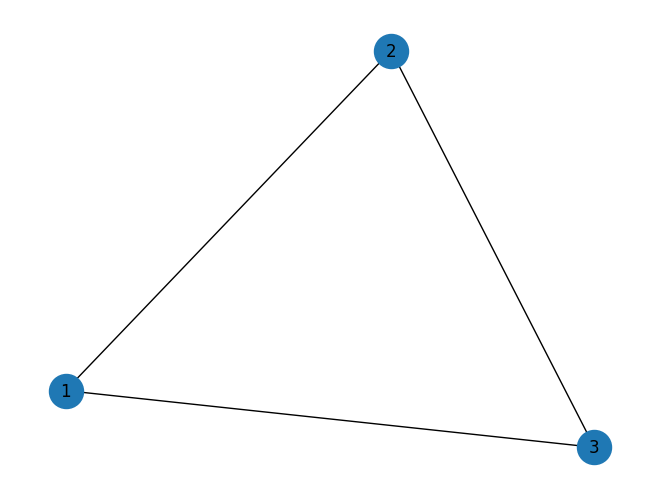

L: 1.0, C: 1.0


In [240]:
import networkx as nx
import matplotlib.pyplot as plt

nodes = [(1, 2), (2, 3), (1, 3)]

G = nx.Graph(nodes)
nx.draw(G, with_labels=True, node_size=600)
plt.show()

# L: 平均最短経路長 
L = nx.average_shortest_path_length(G) 
# C: 平均クラスタリング係数 
C = nx.average_clustering(G)

print(f'L: {L}, C: {C}')

## ネットワークモデル

文献：
https://www.koi.mashykom.com/pdfdocs/network_theory.pdf
https://www.cl.cam.ac.uk/teaching/1819/MLRD/handbook/random-graphs.html

**ERモデル（Erdős–Rényiモデル）**
n: ノードの数
p: エッジが存在する確率


**WSモデル（Watts–Strogatzモデル）**
n: ノードの数
k: 各ノードが接続する近傍ノードの数
p: エッジを再接続する確率（すでにあるエッジ）

手順：
- 1. 近傍k の格子状ネットワークを作る
- 2. 格子状ネットワークのエッジを確率pで再接続する

まず各ノードをリング状に配置し、左右k個ずつの近傍ノードとエッジをつなぐ。
$次数 = 2k$

次に、各エッジを確率pでつなぎ変え、遠くのノードとの繋がりも再現する。
確率pで既存のエッジを削除し、つながってないノードをランダムに選択してエッジをつなぐ。
```
一度切れた近傍エッジが後で復活する → OK
自己ループを作る → NG
すでに存在するエッジを重複して作る → NG
```

- p = 0: 完全な近傍格子
- 0 < p < 1: WSモデル
- p = 1: ERモデル

**BAモデル（Barabási–Albertモデル）**

手順：
- 1. m+1個のノードからなる完全グラフを作る
- 2. 新しいノードを1つずつ追加し、既存のノードにm本のエッジをつなぐ（エッジの接続先は既存ノードの次数に比例する）

完全グラフ：すべてのノードが互いに接続されているグラフ

既存ノードi に新しいノードが接続する確率
$P(i) = \frac{k_i}{\sum_j k_j}$

In [241]:
import random
random.seed(42)

def ER(n, p = 0.05) -> nx.Graph:
    """
    Erdős-Rényiモデル
    ランダムグラフを生成するモデル
    """
    nodes = list(range(n)) # ノード一覧
    edges = [] # エッジ一覧の初期化
    # エッジの作成
    for i in nodes:
        # 各ノードについて他のノードとの接続
        for j in range(i + 1, n):
            if random.random() < p:
                edges.append((i, j))

    model = nx.Graph()
    # ノードの追加
    model.add_nodes_from(nodes)
    # エッジの追加
    model.add_edges_from(edges)

    return model

def WS(n, k=2, p=0.1) -> nx.Graph:
    """
    Watts-Strogatzモデル
    スモールワールドネットワークを生成するモデル
    """
    # ノードの作成
    nodes = list(range(n))
    # 格子モデルのエッジの作成
    grid_edges = []
    # 初期状態の格子状ネットワークの構築
    for i in nodes:
        # 各ノードの左右k個の隣接ノードと接続
        for j in range(1, k + 1):
            grid_edges.append((i, (i + j) % n))  # 隣接ノードとのエッジを追加
    
    ws_edges = grid_edges.copy()  # エッジの初期状態を格子モデルからコピー
    # エッジの再接続
    for i, old_node in grid_edges:
        if random.random() < p:
            # 接続されているノード（自分自身を含む）
            conn_nodes = {i}
            # 既に接続されているノードをセットに追加
            for a, b in ws_edges:
                # (i, <接続ノード>)　のケース
                if a == i:
                    conn_nodes.add(b)
                # (<接続ノード>, i)　のケース
                elif b == i:
                    conn_nodes.add(a)
            # 接続されていないノード（全体 - 接続ノード）を候補とする
            cand_nodes = list(set(nodes) - conn_nodes)  
            if cand_nodes:
                new_node = random.choice(cand_nodes)  # 新しいノードをランダムに選択
                ws_edges.remove((i, old_node))  # 古いエッジを削除
                ws_edges.append((i, new_node))  # 新しいエッジを追加

    model = nx.Graph()
    model.add_nodes_from(nodes)
    model.add_edges_from(ws_edges)

    return model

def BA(n, m=2) -> nx.Graph:
    """
    Barabási-Albertモデル
    スケールフリーネットワークを生成するモデル
    """
    # ノードの作成
    nodes = list(range(m+1))
    # 完全グラフのエッジの作成
    edges = [(i, j) for i in nodes for j in nodes if i < j]
    # BAモデルの作成
    for i in range(m+1, n):
        # 各ノードの次数を計算
        degree = [0] * i
        # 既存のエッジから次数を計算
        for a, b in edges:
            degree[a] += 1
            degree[b] += 1
        # ノードi に新しいノードが接続する確率を計算
        prob = [d / sum(degree) for d in degree]
        # 接続先のノードを確率的に選択
        cand = nodes.copy()
        new_nodes = []
        for _ in range(m):
            new_node = random.choices(cand, weights=prob, k=1)[0]

            # 選択されたノードとその確率を削除し、同じノードを複数回選ばないようにする
            prob.pop(cand.index(new_node))
            cand.remove(new_node)

            new_nodes.append(new_node) # 新しいノードの接続先を保存
        # 新しくノードを追加し接続先のエッジを追加
        nodes.append(i)
        for new_node in new_nodes:
            edges.append((i, new_node))

    model = nx.Graph()
    model.add_nodes_from(nodes)
    model.add_edges_from(edges)

    return model


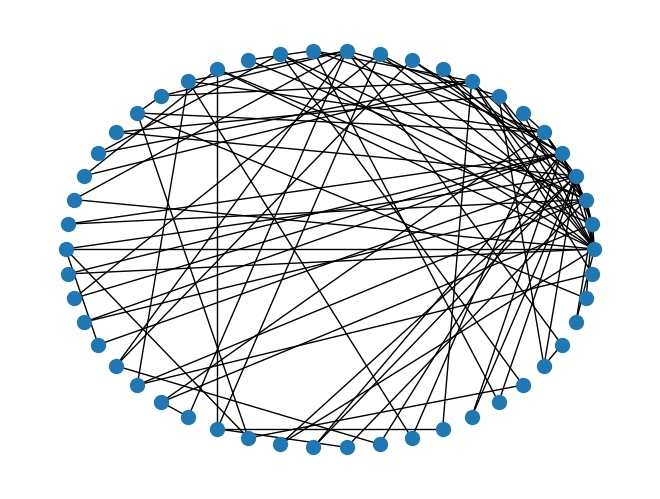

Graph with 50 nodes and 97 edges


In [242]:
## plot

# ノード数
n = 50

# モデルの生成
func = BA
model = func(n)

# 表示
pos = nx.circular_layout(model)
# 円形レイアウトで描画
nx.draw(model, pos, node_size=100)
plt.show()
print(model)

## 感染症モデル

tau: 感染率
- 感染者と未感染者がエッジで接続されている場合、感染者が未感染者を感染させる確率

rho: 初期感染者の割合

gamma: 回復率 (SIS・SIRモデル)

In [243]:
def SI(model: nx.Graph, tau: float, rho: float, times: int = 10):
    # ノードの取得
    nodes = list(model.nodes())
    N = len(nodes)

    # 初期感染者の選択
    infected = set(random.sample(nodes, round(N * rho)))
    status = {node: 'I' if node in infected else 'S' for node in nodes}

    # 結果保存のための初期値
    history = [status.copy()]

    # ステップごとに感染のシミュレーション
    for time in range(times):
        infected_nodes = [node for node in nodes if status[node] == 'I']

        # 感染者から未感染者への感染
        new_infected = set()
        for infected_node in infected_nodes:
            # 感染者の隣接ノードを取得
            neighbors = list(model.neighbors(infected_node))
            for neighbor in neighbors:
                # 隣接ノードが未感染の場合、感染する確率に基づいて感染させる
                if status[neighbor] == 'S' and random.random() < tau:
                    new_infected.add(neighbor)

        # 新たに感染したノードを更新
        for node in new_infected:
            status[node] = 'I'
        
        history.append(status.copy())
    
    return history

def SIS(model: nx.Graph, tau: float, gamma: float, rho: float, times: int = 10):

    # ノードの取得
    nodes = list(model.nodes())
    N = len(nodes)

    # 初期感染者の選択
    infected = set(random.sample(nodes, round(N * rho)))
    status = {node: 'I' if node in infected else 'S' for node in nodes}

    # 結果保存のための初期値
    history = [status.copy()]

    # ステップごとに感染のシミュレーション
    for _ in range(times):
        # 現在の感染者のリストを作成
        infected_nodes = [node for node in nodes if status[node] == 'I']

        # 感染者から未感染者への感染
        new_infected = set()
        for infected_node in infected_nodes:
            # 感染者の隣接ノードを取得
            neighbors = list(model.neighbors(infected_node))
            for neighbor in neighbors:
                # 隣接ノードが未感染の場合、感染する確率に基づいて感染させる
                if status[neighbor] == 'S' and random.random() < tau:
                    new_infected.add(neighbor)

        # 感染者の回復
        # 回復するノードの初期化
        recovered_to_susceptible = set()
        for infected_node in infected_nodes:
            if random.random() < gamma:
                recovered_to_susceptible.add(infected_node)  # 回復したノードを記録


        # 新たに感染したノードを更新
        for node in new_infected:
            status[node] = 'I'

        # 回復するノードを更新
        for node in recovered_to_susceptible:
            status[node] = 'S'
        
        history.append(status.copy())
    
    return history
    

def SIR(model: nx.Graph, tau: float, gamma: float, rho: float, times: int = 10):

    # ノードの取得
    nodes = list(model.nodes())
    N = len(nodes)

    # 初期感染者の選択
    infected = set(random.sample(nodes, round(N * rho)))
    status = {node: 'I' if node in infected else 'S' for node in nodes}

    # 結果保存のための初期値
    history = [status.copy()]

    # ステップごとに感染のシミュレーション
    for _ in range(times):
        # 現在の感染者のリストを作成
        infected_nodes = [node for node in nodes if status[node] == 'I']

        # 感染者から未感染者への感染
        new_infected = set()
        for infected_node in infected_nodes:
            # 感染者の隣接ノードを取得
            neighbors = list(model.neighbors(infected_node))
            for neighbor in neighbors:
                # 隣接ノードが未感染の場合、感染する確率に基づいて感染させる
                if status[neighbor] == 'S' and random.random() < tau:
                    new_infected.add(neighbor)

        # 感染者の回復
        # 回復したノードは 'R' として管理
        recovered = set()
        for infected_node in infected_nodes:
            if random.random() < gamma:
                recovered.add(infected_node)  # 回復したノードを記録

        # 新たに感染したノードを更新
        for node in new_infected:
            status[node] = 'I'

        # 回復するノードを更新
        for node in recovered:
            status[node] = 'R'
        
        history.append(status.copy())
    
    return history


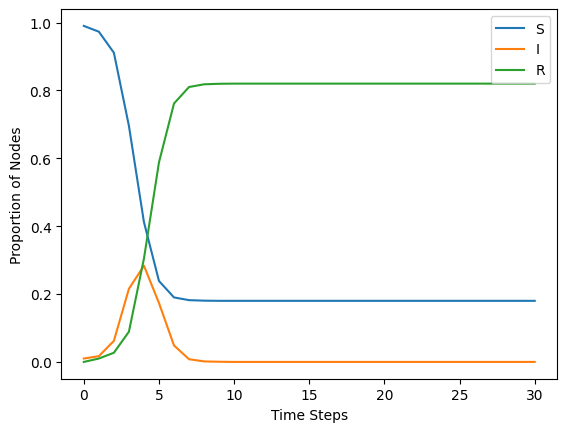

In [244]:
def plot_status_rate(history):
    times = len(history)
    S_rate = []
    I_rate = []
    R_rate = []
    for status in history:
        total = len(status)
        S_count = sum(1 for s in status.values() if s == 'S')
        I_count = sum(1 for s in status.values() if s == 'I')
        R_count = sum(1 for s in status.values() if s == 'R')
        S_rate.append(S_count / total)
        I_rate.append(I_count / total)
        R_rate.append(R_count / total)

    plt.plot(range(times), S_rate, label='S')
    plt.plot(range(times), I_rate, label='I')
    plt.plot(range(times), R_rate, label='R')
    plt.xlabel('Time Steps')
    plt.ylabel('Proportion of Nodes')
    plt.legend()
    plt.show()


n = 2000 # ノード数 (計算量多め, SI: 3000程度, )
model = BA(n, m=4)

tau = 0.3
gamma = 1.0
rho = 0.01

history = SIR(model, tau, gamma, rho, times=30)
plot_status_rate(history)